# Molecular Dynamics with MDAnalysis

This notebook demonstrates the **MDAnalysis compatibility layer** introduced in
**melodia-py v0.1.8**.  It shows how to compute per-residue backbone geometry
directly from a GROMACS trajectory and how the results compare to the
`geometry_from_structure_file` path using a pre-exported PDB ensemble.

**System:** Human ubiquitin (UniProt P0CG47, PDB 1UBQ) — 76 residues,
single α/β fold.  The trajectory covers 1 ns of NPT simulation at 300 K
with a 2 fs time step, sampled every 2 ps for a total of **501 frames**.

**Files used:**

| File | Description |
|---|---|
| `ubiquitin.gro` | GROMACS coordinate file (topology source for MDAnalysis) |
| `ubiquitin.xtc` | Protein-only, PBC-corrected, backbone-fitted trajectory |
| `ubiquitin_ensemble.pdb` | Same trajectory exported as a multi-MODEL PDB via `gmx trjconv` |

> **Google Colab users:** uncomment the `pip install` and `curl` lines in the
> next two cells to install the package and download the input files.



In [3]:
# Uncomment for running in Google Colab
#!pip install melodia-py

In [4]:
import os 

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

The MDAnalysis integration is an optional dependency.  Install it with:

```shell
pip install "melodia-py[mdanalysis]"
```

In [5]:
import MDAnalysis as mda
import melodia_py as mel

## Input files

The three input files are hosted in the melodia-py GitHub repository.
Uncomment the cells below if you are running in Google Colab or any
environment where the files are not already present.


In [6]:
# Uncomment for running in Google Colab
#! curl -OJL https://github.com/rwmontalvao/melodia_py/raw/main/examples/ubiquitin.gro
#! curl -OJL https://github.com/rwmontalvao/melodia_py/raw/main/examples/ubiquitin.xtc
#! curl -OJL https://github.com/rwmontalvao/melodia_py/raw/main/examples/ubiquitin_ensemble.pdb

## 1  Single-frame geometry from an MD trajectory

`geometry_from_mdanalysis` accepts a `frames` parameter — a list of 0-based
frame indices.  Passing `frames=[0]` extracts only the first snapshot, which
is equivalent to loading `ubiquitin.gro` directly as a static structure.

Each row in the returned DataFrame corresponds to one residue.
The `model` column holds the frame index; all other columns — `curvature`,
`torsion`, `arc_length`, `writhing`, `phi`, `psi` — have the same meaning
and units as in `geometry_from_structure_file`.

Terminal residues (MET 1 and GLY 76) receive `NaN` for `phi` and `psi`
respectively, because the dihedral angles are undefined at chain termini.


In [7]:
gro = "ubiquitin.gro"
xtc = "ubiquitin.xtc"
pdb = "ubiquitin_ensemble.pdb"

Load the Universe and extract frame 0 into a DataFrame:

In [8]:
u = mda.Universe(str(gro), str(xtc))
df_mda = mel.geometry_from_mdanalysis(u, frames=[0])
df_mda = df_mda.sort_values("order").reset_index(drop=True) 

Inspect the result — 76 rows, one per residue:

In [9]:
df_mda

,id,model,code,chain,order,name,curvature,torsion,arc_length,writhing,phi,psi
0,0,0,UBIQUITIN,SYSTEM,1,MET,0.640538,-0.020202,7.670671,-0.006133,NaN,149.490359
1,1,0,UBIQUITIN,SYSTEM,2,GLN,0.640538,-0.020202,7.709143,-0.006133,-87.109814,146.717009
2,2,0,UBIQUITIN,SYSTEM,3,ILE,0.481139,-0.099004,7.770274,-0.006133,-132.507065,171.322041
3,3,0,UBIQUITIN,SYSTEM,4,PHE,0.612023,-0.135369,7.794524,-0.017471,-113.169459,150.533906
4,4,0,UBIQUITIN,SYSTEM,5,VAL,0.816647,-0.118113,7.900119,-0.021025,-127.687328,134.928176
...,...,...,...,...,...,...,...,...,...,...,...,...
71,71,0,UBIQUITIN,SYSTEM,72,ARG,0.224551,-0.727952,7.814951,-0.011833,-91.026876,124.163491
72,72,0,UBIQUITIN,SYSTEM,73,LEU,0.071048,-1.040620,7.851121,-0.015426,-105.912678,176.423072
73,73,0,UBIQUITIN,SYSTEM,74,ARG,0.325634,-0.335969,7.934962,0.001426,-139.978641,56.793882
74,74,0,UBIQUITIN,SYSTEM,75,GLY,0.201450,0.190742,7.982690,0.001426,179.363342,106.084405


## 2  Full trajectory — all 501 frames

Omitting the `frames` argument (or passing `frames=None`) processes every
frame in the trajectory.  For multi-frame workloads the `n_jobs` parameter
distributes frames across CPU cores using joblib.  Here we use `n_jobs=8`;
set `n_jobs=-1` to use all available cores automatically.

The output DataFrame has **501 × 76 = 38 076 rows** — one per
(frame, residue) pair.  The `model` column runs from 0 to 500.


In [10]:
%time df_mda_all = mel.geometry_from_mdanalysis(u, n_jobs=8)

CPU times: user 1.82 s, sys: 94.9 ms, total: 1.92 s
Wall time: 7.83 s


Inspect the full-trajectory DataFrame:

In [11]:
df_mda_all

,id,model,code,chain,order,name,curvature,torsion,arc_length,writhing,phi,psi
0,0,0,UBIQUITIN,SYSTEM,1,MET,0.640538,-0.020202,7.670671,-0.006133,NaN,149.490359
1,1,0,UBIQUITIN,SYSTEM,2,GLN,0.640538,-0.020202,7.709143,-0.006133,-87.109814,146.717009
2,2,0,UBIQUITIN,SYSTEM,3,ILE,0.481139,-0.099004,7.770274,-0.006133,-132.507065,171.322041
3,3,0,UBIQUITIN,SYSTEM,4,PHE,0.612023,-0.135369,7.794524,-0.017471,-113.169459,150.533906
4,4,0,UBIQUITIN,SYSTEM,5,VAL,0.816647,-0.118113,7.900119,-0.021025,-127.687328,134.928176
...,...,...,...,...,...,...,...,...,...,...,...,...
38071,71,500,UBIQUITIN,SYSTEM,72,ARG,0.385518,-0.303830,7.900400,-0.002255,-144.555763,55.000939
38072,72,500,UBIQUITIN,SYSTEM,73,LEU,0.134935,-0.319596,7.873005,-0.003341,-74.435558,156.611917
38073,73,500,UBIQUITIN,SYSTEM,74,ARG,0.206153,-0.885932,7.964241,-0.034499,-120.688865,-17.242164
38074,74,500,UBIQUITIN,SYSTEM,75,GLY,0.201861,-0.309700,7.915320,-0.034499,157.531956,-155.710657


### Curvature–torsion density (MDAnalysis path)

A kernel-density joint plot of curvature vs. torsion over the entire
trajectory.  The dense cluster near (0.35, 0.25) corresponds to the
regular β-sheet and α-helix residues; the diffuse tail at high curvature
and negative torsion reflects loop and turn conformations sampled during
the simulation.

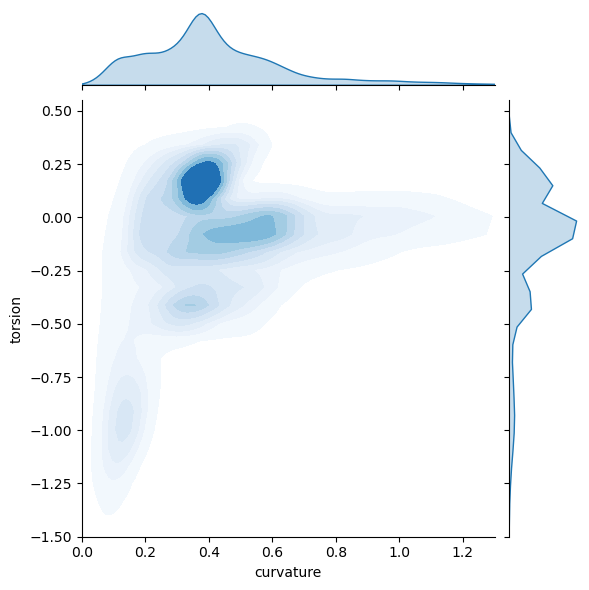

In [13]:
cmap = sns.color_palette('Blues', as_cmap=True)
sns.jointplot(x='curvature', y='torsion', data=df_mda_all, kind='kde', cmap=cmap, xlim=[0.0, 1.3], ylim=[-1.5, 0.55], fill=True);

## 3  Comparison with the BioPython path

`geometry_from_structure_file` processes the same trajectory exported as a
multi-MODEL PDB ensemble by `gmx trjconv`.  Each `MODEL`/`ENDMDL` block
becomes one entry in the `model` column — identical to how
`geometry_from_mdanalysis` maps trajectory frames.

Comparing both DataFrames confirms numerical consistency between the two
entry points.  Small differences (< 10⁻³) arise from the limited coordinate
precision of the PDB format (3 decimal places in Ångströms) versus the
32-bit float storage of the XTC file.


In [12]:
%time dfi_ensemble = mel.geometry_from_structure_file(pdb, n_jobs=8)

CPU times: user 2.33 s, sys: 156 ms, total: 2.48 s
Wall time: 6.85 s


Exception ignored in: <function ResourceTracker.__del__ at 0x772ee6087d80>
Traceback (most recent call last):
  File "/home/rmontalvao/miniforge3/envs/melodia_py/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/rmontalvao/miniforge3/envs/melodia_py/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/rmontalvao/miniforge3/envs/melodia_py/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7c8b53a87d80>
Traceback (most recent call last):
  File "/home/rmontalvao/miniforge3/envs/melodia_py/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/rmontalvao/miniforge3/envs/melodia_py/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/rmontalvao/miniforge3/envs/melodia_py/lib/python3.13/multiprocessing/resource_tracker.py",

Inspect the ensemble DataFrame — same shape as `df_mda_all`:

In [15]:
dfi_ensemble

,id,model,code,chain,order,name,curvature,torsion,arc_length,writhing,phi,psi
0,0,0,UBIQUITIN_ENSEMBLE,,1,MET,0.640537,-0.020202,7.670669,-0.006133,NaN,149.490280
1,1,0,UBIQUITIN_ENSEMBLE,,2,GLN,0.640537,-0.020202,7.709142,-0.006133,-87.109564,146.716857
2,2,0,UBIQUITIN_ENSEMBLE,,3,ILE,0.481138,-0.099004,7.770268,-0.006133,-132.507257,171.322233
3,3,0,UBIQUITIN_ENSEMBLE,,4,PHE,0.612022,-0.135369,7.794516,-0.017471,-113.169476,150.533663
4,4,0,UBIQUITIN_ENSEMBLE,,5,VAL,0.816645,-0.118113,7.900122,-0.021025,-127.687379,134.928206
...,...,...,...,...,...,...,...,...,...,...,...,...
38071,71,500,UBIQUITIN_ENSEMBLE,,72,ARG,0.385517,-0.303831,7.900403,-0.002255,-144.555752,55.000805
38072,72,500,UBIQUITIN_ENSEMBLE,,73,LEU,0.134935,-0.319597,7.873005,-0.003341,-74.435360,156.611664
38073,73,500,UBIQUITIN_ENSEMBLE,,74,ARG,0.206154,-0.885930,7.964246,-0.034499,-120.688614,-17.242174
38074,74,500,UBIQUITIN_ENSEMBLE,,75,GLY,0.201861,-0.309699,7.915323,-0.034499,157.531857,-155.710705


### Curvature–torsion density (BioPython / PDB ensemble path)

The joint plot is visually indistinguishable from the MDAnalysis version,
confirming that both entry points produce equivalent geometry descriptors
from the same underlying trajectory.

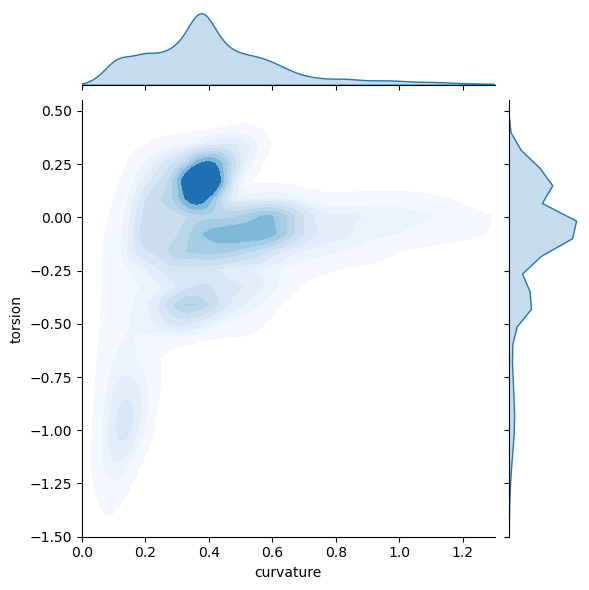

In [16]:
cmap = sns.color_palette('Blues', as_cmap=True)
sns.jointplot(x='curvature', y='torsion', data=dfi_ensemble, kind='kde', cmap=cmap, xlim=[0.0, 1.3], ylim=[-1.5, 0.55], fill=True);

## 4  Per-residue geometry along the sequence

To visualise how curvature and torsion vary along the polypeptide chain
and how much they fluctuate across frames, we reshape the DataFrame from
wide to long format using `pd.DataFrame.melt`.  This gives a single
`value` column with a `metric` label (`curvature` or `torsion`), which
seaborn's `lineplot` can use directly to draw mean ± spread bands.

In [35]:
df_melt = df_mda_all.melt(
    id_vars=['order', 'model'],
    value_vars=['curvature', 'torsion'],
    var_name='metric',
    value_name='value'
)

### Combined view — curvature and torsion on a shared axis

Mean ± 1 SD per residue position across all 501 frames.  Curvature is
always positive and peaks at structurally irregular positions (turns,
loops).  Torsion fluctuates around zero for regular secondary structure
and becomes strongly negative in the C-terminal loop region
(residues 72–76), reflecting its inherent flexibility.


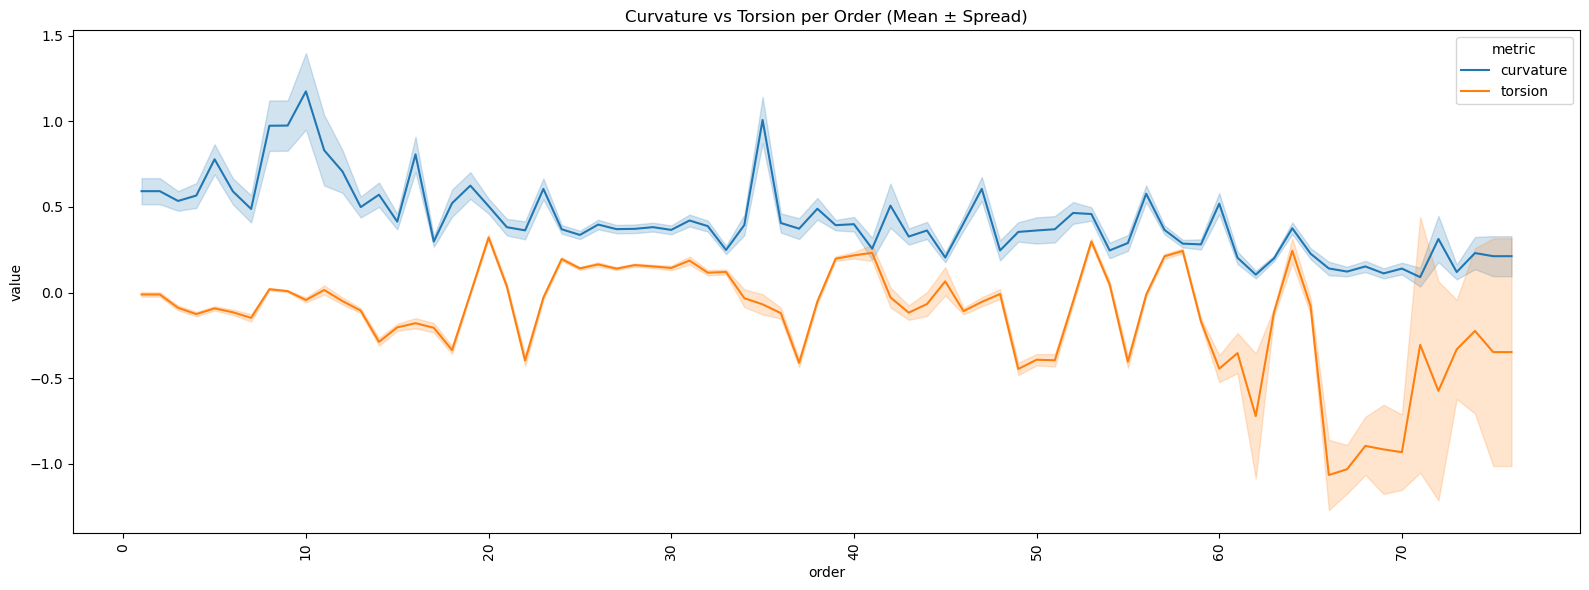

In [37]:
plt.figure(figsize=(16, 6))

sns.lineplot(
    data=df_melt,
    x='order',
    y='value',
    hue='metric',
    errorbar='sd'  # or ('ci', 95)
)

plt.title('Curvature vs Torsion per Order (Mean ± Spread)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Combined view — curvature and torsion on a shared axis

Mean ± 1 SD per residue position across all 501 frames.  Curvature is
always positive and peaks at structurally irregular positions (turns,
loops).  Torsion fluctuates around zero for regular secondary structure
and becomes strongly negative in the C-terminal loop region
(residues 72–76), reflecting its inherent flexibility.


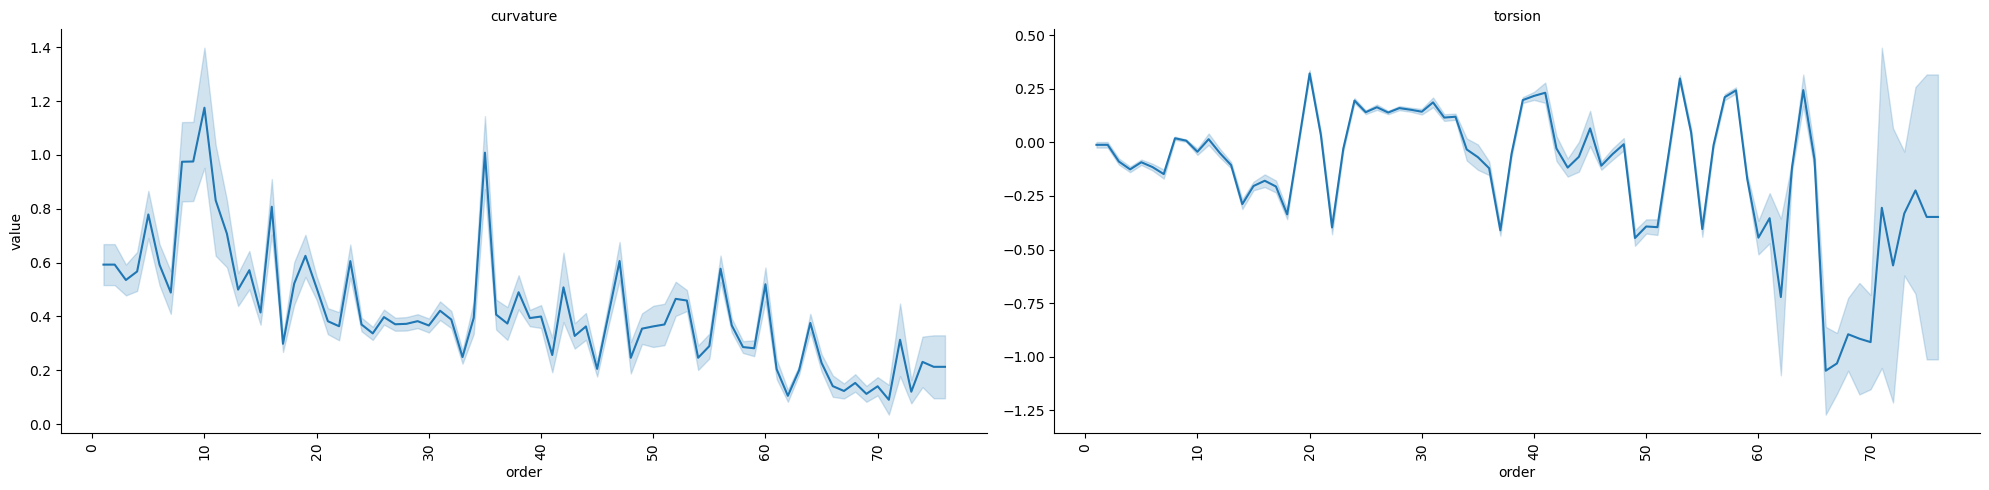

In [34]:
g = sns.FacetGrid(df_melt, col="metric", sharey=False, height=5, aspect=2)

g.map_dataframe(
    sns.lineplot,
    x='order',
    y='value',
    errorbar='sd'
)

g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()